# Módulo 11. Segmentación de municipios y simulación de escenarios

En este módulo se complementa el sistema de alertas mediante dos técnicas adicionales.

En primer lugar, se emplea un algoritmo de aprendizaje no supervisado (K-Means) para identificar grupos de municipios con características educativas similares.

Posteriormente, se desarrolla un caso de estudio basado en un municipio real, con el fin de evaluar cómo podrían variar las predicciones del modelo ante posibles mejoras en algunos indicadores educativos. Este ejercicio ilustra el potencial del modelo como herramienta de apoyo para la toma de decisiones.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [3]:
PROJECT_ROOT = Path.cwd().parent

df = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "processed" /
    "dataset_modelado.csv"
)

print(df.shape)

df.head()

(15707, 85)


,AÑO,CÓDIGO_MUNICIPIO,MUNICIPIO,CÓDIGO_DEPARTAMENTO,DEPARTAMENTO,CÓDIGO_ETC,ETC,POBLACIÓN_5_16,TASA_MATRICULACIÓN_5_16,COBERTURA_NETA,...,REPITENCIA_MEDIA_ETC,BENEFICIARIOS_PAE,BRECHA_COBERTURA,BRECHA_APROBACION,INDICE_EFICIENCIA,PRESION_SISTEMA,DIGITALIZADO,TAM_GRUPO_NORMALIZADO,PESO_MUNICIPIO_ETC,PANDEMIA
0,2024,5004,Abriaquí,5,Antioquia,3758.0,Antioquia (ETC),499.0,56.11,56.11,...,3.35,NaN,5.81,99.36,11.418099,8.893245,0,NaN,0.001007,0
1,2024,15204,Cómbita,15,Boyacá,3769.0,Boyacá (ETC),1862.0,95.33,95.33,...,3.21,NaN,96.18,91.52,6.821739,19.532151,0,NaN,0.011952,0
2,2024,99773,Cumaribo,99,Vichada,3832.0,Vichada (ETC),25239.0,50.70,50.70,...,4.08,NaN,7.04,64.06,1.940284,497.810651,0,NaN,0.750245,0
3,2024,99624,Santa Rosalía,99,Vichada,3832.0,Vichada (ETC),1157.0,81.42,81.42,...,4.08,NaN,9.16,78.44,3.176015,14.210268,0,NaN,0.034393,0
4,2024,99524,La Primavera,99,Vichada,3832.0,Vichada (ETC),2645.0,90.96,90.96,...,4.08,NaN,8.17,77.18,3.169123,29.078716,0,NaN,0.078624,0


In [4]:
variables_cluster = [

    "COBERTURA_NETA",

    "DESERCIÓN",

    "APROBACIÓN",

    "REPROBACIÓN",

    "REPITENCIA",

    "BRECHA_COBERTURA",

    "INDICE_EFICIENCIA",

    "PRESION_SISTEMA"

]

cluster_df = df[variables_cluster].copy()

cluster_df = cluster_df.fillna(cluster_df.median())

scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_df)

## Preparación de los datos para el agrupamiento

Para identificar grupos de municipios con características similares, se seleccionaron algunos de los indicadores educativos más representativos del proyecto.

Estas variables describen aspectos relacionados con la cobertura, permanencia, eficiencia y presión sobre el sistema educativo. Posteriormente, los datos son estandarizados para garantizar que todas las variables tengan la misma escala antes de aplicar el algoritmo K-Means.

In [5]:
variables_cluster = [
    "COBERTURA_NETA",
    "DESERCIÓN",
    "APROBACIÓN",
    "REPROBACIÓN",
    "REPITENCIA",
    "BRECHA_COBERTURA",
    "INDICE_EFICIENCIA"
]

cluster_df = df[variables_cluster].copy()

# Imputación sencilla
cluster_df = cluster_df.fillna(cluster_df.median())

# Escalamiento
scaler = StandardScaler()
X_cluster = scaler.fit_transform(cluster_df)

print("Dimensiones:", X_cluster.shape)

Dimensiones: (15707, 7)


## Aplicación del algoritmo K-Means

Se utiliza el algoritmo K-Means para agrupar automáticamente los municipios de acuerdo con la similitud de sus indicadores educativos.

En este trabajo se establecieron cuatro grupos, buscando obtener una segmentación sencilla que facilite la interpretación de los resultados y la identificación de perfiles territoriales.

In [6]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_cluster)

df["Cluster"].value_counts().sort_index()

Cluster
0    5246
1    2967
2    3379
3    4115
Name: count, dtype: int64

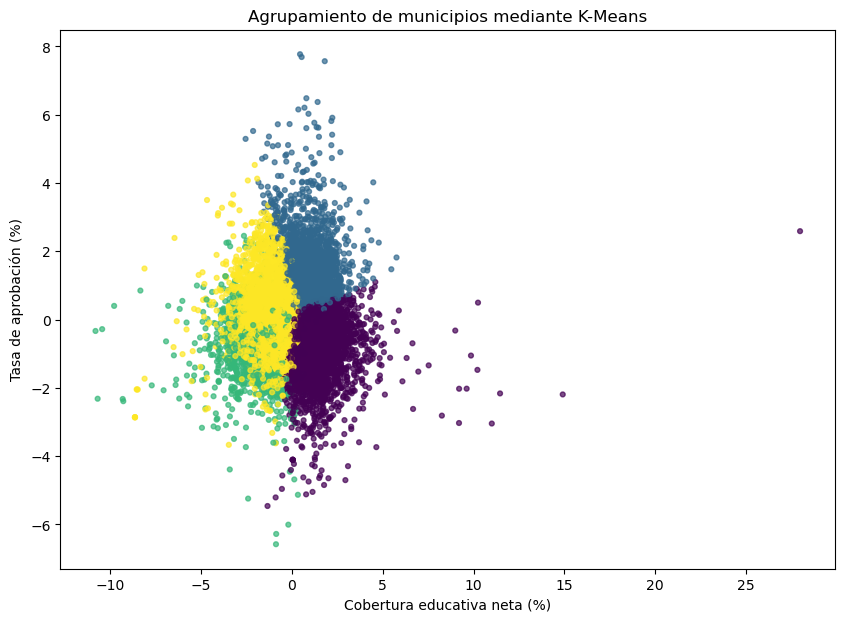

In [7]:
pca = PCA(n_components=2)

componentes = pca.fit_transform(X_cluster)

plt.figure(figsize=(10,7))

plt.scatter(
    componentes[:,0],
    componentes[:,1],
    c=df["Cluster"],
    s=12,
    alpha=0.7
)

plt.title("Agrupamiento de municipios mediante K-Means")
plt.xlabel("Cobertura educativa neta (%)")
plt.ylabel("Tasa de aprobación (%)")

plt.show()

## Caracterización de los grupos encontrados

Una vez identificados los grupos de municipios mediante K-Means, es necesario analizar las características promedio de cada uno de ellos.

Este análisis permite comprender qué distingue a cada grupo en términos de cobertura, deserción, aprobación, repitencia y otros indicadores educativos, facilitando la interpretación de los resultados y su posible utilización en la formulación de políticas públicas diferenciadas.

In [8]:
perfil_clusters = (
    df.groupby("Cluster")[
        [
            "DESERCIÓN",
            "COBERTURA_NETA",
            "APROBACIÓN",
            "REPROBACIÓN",
            "REPITENCIA",
            "BRECHA_COBERTURA",
            "INDICE_EFICIENCIA"
        ]
    ]
    .mean()
    .round(2)
)

perfil_clusters

,DESERCIÓN,COBERTURA_NETA,APROBACIÓN,REPROBACIÓN,REPITENCIA,BRECHA_COBERTURA,INDICE_EFICIENCIA
Cluster,,,,,,,
0,2.29,77.96,95.70,1.99,2.51,7.94,22.21
1,3.12,99.62,94.06,2.74,2.05,21.58,15.57
2,3.79,84.03,88.20,8.01,8.87,9.75,4.54
3,5.03,84.97,87.20,7.35,2.03,11.60,6.51


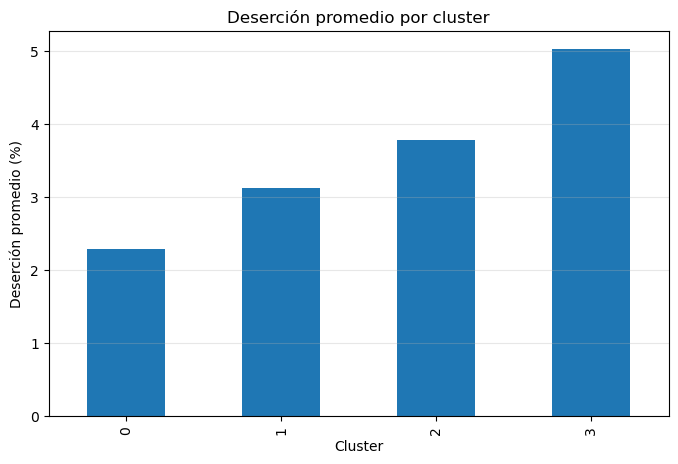

In [9]:
perfil_clusters["DESERCIÓN"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Deserción promedio (%)")
plt.title("Deserción promedio por cluster")
plt.grid(axis="y", alpha=0.3)

plt.show()

## Interpretación de los clusters

El algoritmo K-Means permitió identificar cuatro perfiles de municipios con comportamientos educativos diferenciados.

Al analizar los valores promedio de cada indicador, se observa que los grupos presentan diferencias importantes en términos de cobertura, aprobación, repitencia y deserción escolar.

Esta segmentación permite identificar perfiles territoriales que podrían beneficiarse de estrategias de intervención específicas, complementando el sistema de alertas desarrollado anteriormente.

### Conclusión del análisis de agrupamiento

El análisis de clustering permitió identificar cuatro perfiles diferenciados de municipios colombianos.

Los resultados muestran que existen territorios con indicadores educativos consistentemente favorables, mientras que otros concentran mayores niveles de deserción, reprobación y baja eficiencia interna.

Esta segmentación puede servir como herramienta para orientar estrategias de intervención focalizadas, permitiendo que las políticas públicas respondan a las necesidades particulares de cada grupo de municipios.